In [7]:
import pandas as pd

df = pd.read_csv("/content/Amazon Sale Report.csv",low_memory=False)

df.head()

,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,...,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,Unnamed: 22
0,0,405-8078784-5731545,04-30-22,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,...,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,NaN,False,Easy Ship,NaN
1,1,171-9198151-1101146,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,...,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
2,2,404-0687676-7273146,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,...,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,True,NaN,NaN
3,3,403-9615377-8133951,04-30-22,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,Western Dress,...,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN,NaN,False,Easy Ship,NaN
4,4,407-1069790-7240320,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,...,INR,574.00,CHENNAI,TAMIL NADU,600073.0,IN,NaN,False,NaN,NaN


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128975 entries, 0 to 128974
Data columns (total 24 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   index               128975 non-null  int64  
 1   Order ID            128975 non-null  object 
 2   Date                128975 non-null  object 
 3   Status              128975 non-null  object 
 4   Fulfilment          128975 non-null  object 
 5   Sales Channel       128975 non-null  object 
 6   ship-service-level  128975 non-null  object 
 7   Style               128975 non-null  object 
 8   SKU                 128975 non-null  object 
 9   Category            128975 non-null  object 
 10  Size                128975 non-null  object 
 11  ASIN                128975 non-null  object 
 12  Courier Status      122103 non-null  object 
 13  Qty                 128975 non-null  int64  
 14  currency            121180 non-null  object 
 15  Amount              121180 non-nul

In [9]:
df.isnull().sum()


,0
index,0
Order ID,0
Date,0
Status,0
Fulfilment,0
Sales Channel,0
ship-service-level,0
Style,0
SKU,0
Category,0


In [10]:
df = df.drop_duplicates()

In [11]:
df.drop(columns=["Unnamed: 22"], inplace=True)

In [12]:
df = df.dropna(subset=["Amount"])

In [15]:
df["Date"] = pd.to_datetime(df["Date"])

In [16]:
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day

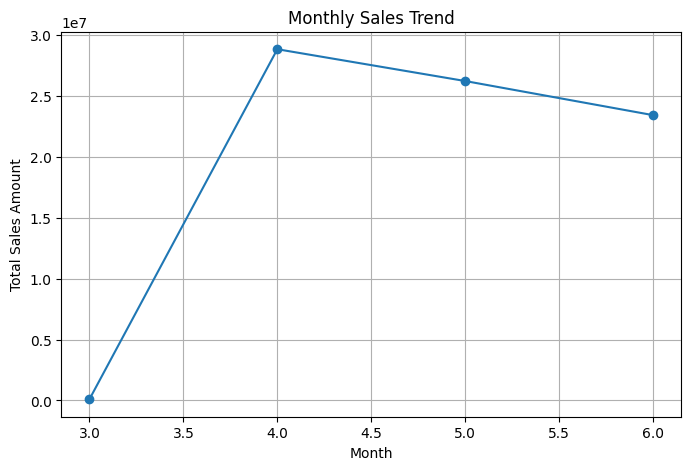

In [17]:
import matplotlib.pyplot as plt

monthly_sales = df.groupby("Month")["Amount"].sum()

plt.figure(figsize=(8, 5))
plt.plot(monthly_sales.index, monthly_sales.values, marker="o")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales Amount")
plt.grid(True)
plt.show()

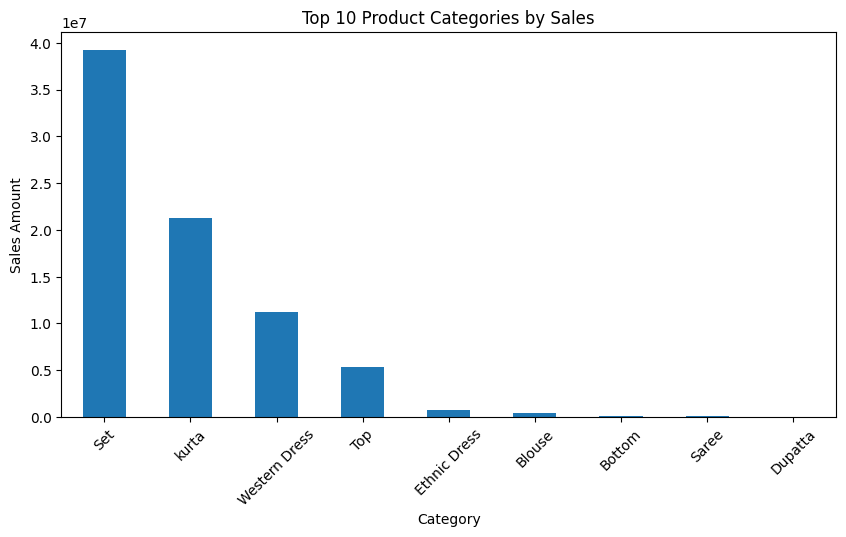

In [18]:
category_sales = df.groupby("Category")["Amount"].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
category_sales.head(10).plot(kind="bar")
plt.title("Top 10 Product Categories by Sales")
plt.xlabel("Category")
plt.ylabel("Sales Amount")
plt.xticks(rotation=45)
plt.show()

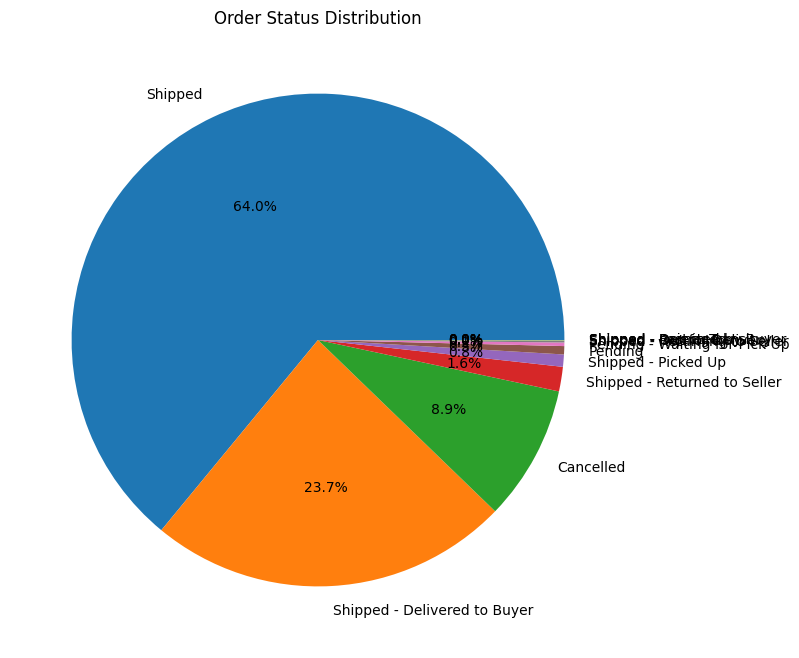

In [19]:
plt.figure(figsize=(8, 8))
df["Status"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Order Status Distribution")
plt.ylabel("")
plt.show()

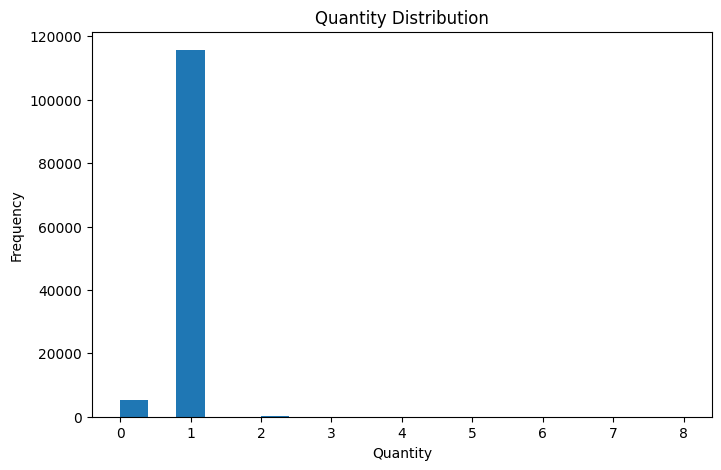

In [20]:
plt.figure(figsize=(8, 5))
plt.hist(df["Qty"], bins=20)

plt.title("Quantity Distribution")
plt.xlabel("Quantity")
plt.ylabel("Frequency")

plt.show()

In [21]:
features = [
    "Qty",
    "Month",
    "Day"
]

X = df[features]

y = df["Amount"]

print(X.head())
print(y.head())

   Qty  Month  Day
0    0      4   30
1    1      4   30
2    1      4   30
3    0      4   30
4    1      4   30
0    647.62
1    406.00
2    329.00
3    753.33
4    574.00
Name: Amount, dtype: float64


In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", X_train.shape)
print("Testing samples:", X_test.shape)

Training samples: (96944, 3)
Testing samples: (24236, 3)


In [23]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [24]:
y_pred = model.predict(X_test)

print(y_pred[:5])

[628.4584166  633.37233097 672.58583446 639.37822632 667.67192008]


In [25]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R² Score:", r2)

Mean Absolute Error (MAE): 217.77718194667042
Mean Squared Error (MSE): 78663.05430227862
Root Mean Squared Error (RMSE): 280.46934645746694
R² Score: 0.0048888727021209055


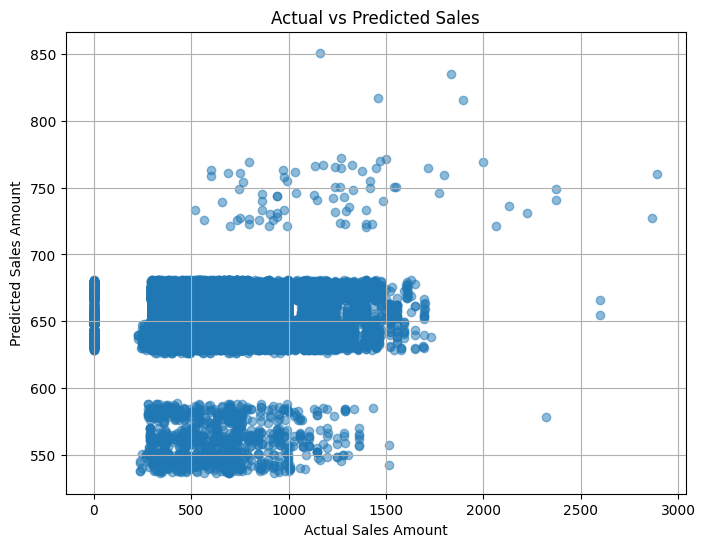

In [26]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, alpha=0.5)

plt.xlabel("Actual Sales Amount")
plt.ylabel("Predicted Sales Amount")
plt.title("Actual vs Predicted Sales")

plt.grid(True)
plt.show()